# Are Boston Marathon Qualifying Times Fair?
## A Three-Framework Comparative Analysis

**Author:** Jeremy Lee ([github.com/lyhjeremy](https://github.com/lyhjeremy))  
**Date:** May 2026  
**Repository:** [boston-bq-fairness](https://github.com/lyhjeremy/boston-bq-fairness)

---

### Research Question

The BAA publishes qualifying times across 22 age-gender brackets but has never disclosed the methodology behind them. This notebook examines whether current BQ standards represent **equal difficulty** across all brackets using three independent frameworks:

1. **World Record Multiplier** — BQ time as a multiple of the bracket's world record
2. **Top-3 Records** — Robustness check using averaged top performances
3. **WMA Age-Graded Scoring** — Difficulty relative to age-specific biological potential

### Scope & Limitations
- Men and women only (non-binary excluded due to insufficient data)
- 2026 Boston Marathon qualifying standards and field size as baseline
- All data from public sources, verified against World Athletics and WMA


In [1]:
import os
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Find the project root no matter where this notebook is launched from ──
# Walks up from the current directory looking for the 'data/' folder.
# Works in VS Code, Jupyter Lab, Jupyter Notebook, Anaconda — anywhere.
def find_project_root():
    cur = os.path.abspath(os.getcwd())
    for _ in range(5):  # walk up at most 5 levels
        if os.path.isdir(os.path.join(cur, 'data')) and \
           os.path.isfile(os.path.join(cur, 'data', 'bq_standards_2026.csv')):
            return cur
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent
    return None

root = find_project_root()
if root is None:
    raise FileNotFoundError(
        "Could not find project root. Make sure you opened the 'boston-bq-fairness' "
        "folder in VS Code, then launch this notebook from inside the notebooks/ subfolder."
    )
os.chdir(root)
print(f"Working from: {os.getcwd()}")

# Plotting defaults
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.edgecolor': '#CCCCCC',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.color': '#CCCCCC',
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.dpi': 120,
})

BLUE = '#2563EB'   # men
RED = '#DC2626'    # women
GREEN = '#059669'  # alternative

def time_str(seconds):
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = int(seconds % 60)
    return f"{h}:{m:02d}:{s:02d}"

print("Setup complete ✓")


Working from: c:\Users\Jeremy\Data Projects\Project 1 Boston Marathon BQ Fairness Analysis\boston-bq-fairness
Setup complete ✓


## 1. Data Loading

We load four datasets:
- **BQ Standards**: 2026 qualifying times from [baa.org](https://www.baa.org/races/boston-marathon/qualify/)
- **World Records**: Open and masters marathon records from World Athletics / Wikipedia
- **WMA Age Factors**: 2023 age-grading factors for marathon
- **Field Size**: 2026 Boston Marathon acceptance data


In [2]:
# Load datasets
bq = pd.read_csv('data/bq_standards_2026.csv')
wr = pd.read_csv('data/world_records.csv')
wma = pd.read_csv('data/wma_age_factors.csv')
field = pd.read_csv('data/field_size_2026.csv')

# Merge into single analysis DataFrame
df = bq.merge(wr[['age_group', 'gender', 'wr_time_seconds', 'athlete', 'year']],
              on=['age_group', 'gender'], how='left')
df = df.merge(wma[['age_group', 'gender', 'midpoint_age', 'wma_factor']],
              on=['age_group', 'gender'], how='left')

print(f"Loaded {len(df)} brackets")
print(f"2026 field: {field[field['metric']=='accepted_qualifiers']['value'].values[0]:,} accepted")
print(f"Cutoff: {field[field['metric']=='cutoff_seconds']['value'].values[0]} seconds under BQ")
df[['age_group', 'gender', 'bq_time_hhmmss', 'wr_time_seconds', 'wma_factor']].head(10)


Loaded 22 brackets
2026 field: 24,362 accepted
Cutoff: 274 seconds under BQ


,age_group,gender,bq_time_hhmmss,wr_time_seconds,wma_factor
0,18-34,M,2:55:00,7170,1.000
1,18-34,W,3:25:00,7796,1.000
2,35-39,M,3:00:00,7170,0.988
3,35-39,W,3:30:00,7796,0.982
4,40-44,M,3:05:00,7455,0.958
5,40-44,W,3:35:00,8547,0.945
6,45-49,M,3:15:00,7752,0.920
7,45-49,W,3:45:00,8494,0.901
8,50-54,M,3:20:00,8369,0.876
9,50-54,W,3:50:00,9065,0.852


## 2. Framework 1: World Record Multiplier

For each bracket:
$$\text{multiplier} = \frac{\text{BQ time}}{\text{World Record time}}$$

A fair system would give every bracket the **same multiplier**. Deviations tell us which brackets are relatively easier or harder.


In [3]:
# Compute WR multiplier
df['wr_multiplier'] = df['bq_time_seconds'] / df['wr_time_seconds']

# Summary statistics
print("=== Framework 1: WR Multiplier ===")
print(f"Mean:   {df['wr_multiplier'].mean():.3f}x")
print(f"Median: {df['wr_multiplier'].median():.3f}x")
print(f"Std:    {df['wr_multiplier'].std():.3f}")
print(f"CV:     {df['wr_multiplier'].std() / df['wr_multiplier'].mean() * 100:.2f}%")
print()

for g in ['M', 'W']:
    sub = df[df['gender'] == g]
    cv = sub['wr_multiplier'].std() / sub['wr_multiplier'].mean() * 100
    print(f"  {g}: mean={sub['wr_multiplier'].mean():.3f}x, CV={cv:.2f}%")

# Welch t-test
m_vals = df[df['gender'] == 'M']['wr_multiplier']
w_vals = df[df['gender'] == 'W']['wr_multiplier']
t_stat, p_val = stats.ttest_ind(m_vals, w_vals, equal_var=False)
print(f"\nWelch t-test: t={t_stat:.3f}, p={p_val:.3f}")

# Levene's test
lev_stat, lev_p = stats.levene(m_vals, w_vals)
print(f"Levene test:  W={lev_stat:.3f}, p={lev_p:.3f}")


=== Framework 1: WR Multiplier ===
Mean:   1.492x
Median: 1.499x
Std:    0.071
CV:     4.75%

  M: mean=1.488x, CV=1.89%
  W: mean=1.495x, CV=6.59%

Welch t-test: t=-0.246, p=0.810
Levene test:  W=5.038, p=0.036


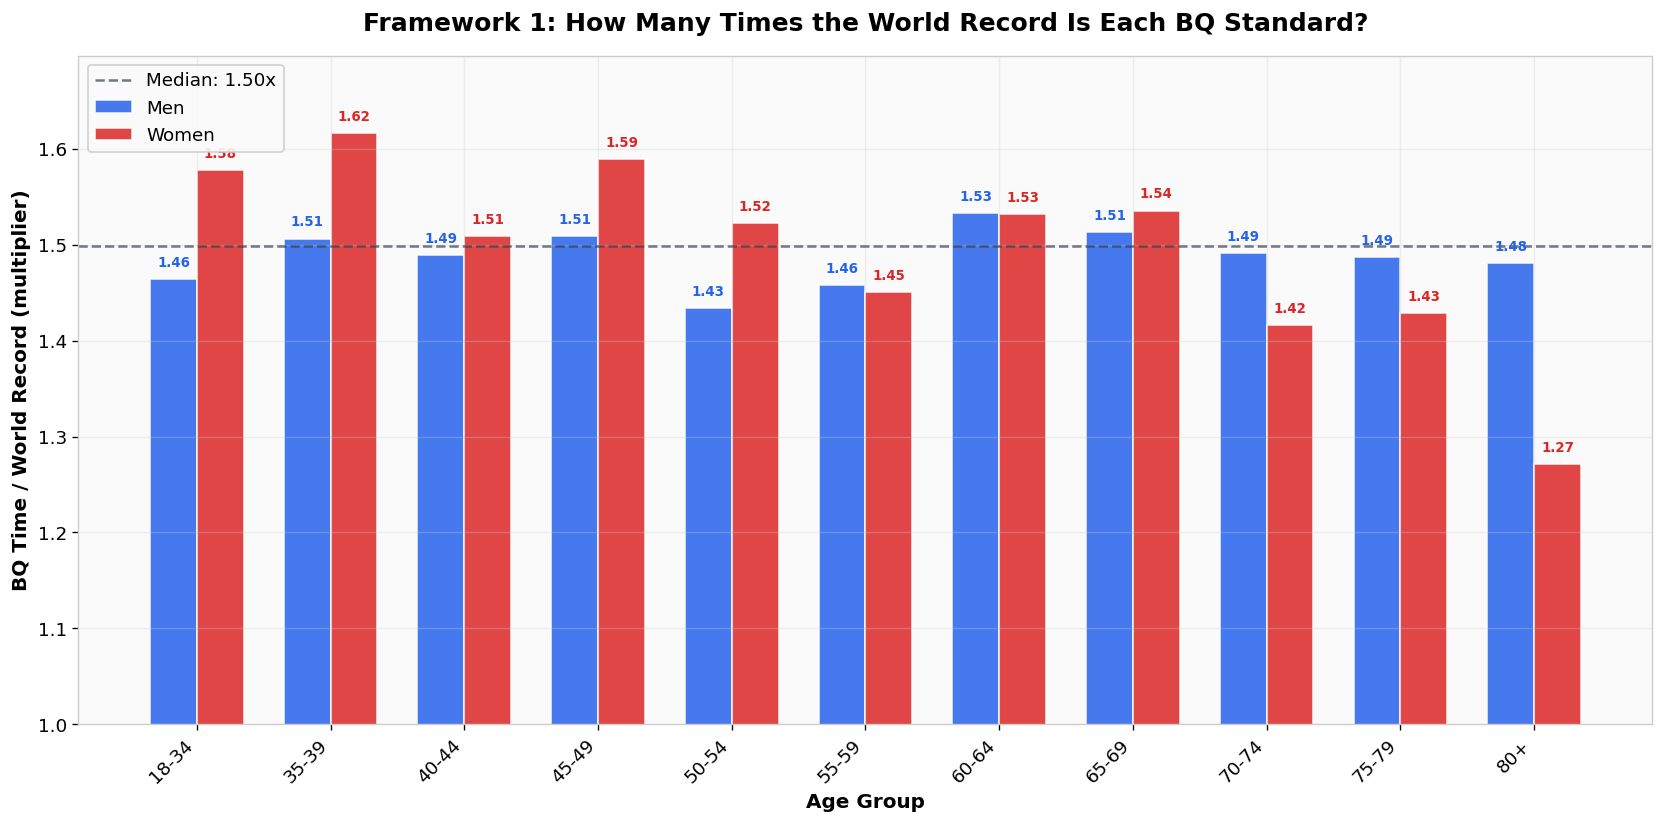

In [4]:
# Figure 1: WR Multiplier by bracket
fig, ax = plt.subplots(figsize=(14, 7))

age_groups = df['age_group'].unique()
x = np.arange(len(age_groups))
width = 0.35

men = df[df['gender'] == 'M'].set_index('age_group').loc[age_groups]
women = df[df['gender'] == 'W'].set_index('age_group').loc[age_groups]

bars_m = ax.bar(x - width/2, men['wr_multiplier'], width, color=BLUE, alpha=0.85, label='Men', edgecolor='white')
bars_w = ax.bar(x + width/2, women['wr_multiplier'], width, color=RED, alpha=0.85, label='Women', edgecolor='white')

median = df['wr_multiplier'].median()
ax.axhline(y=median, color='#374151', linestyle='--', alpha=0.7, linewidth=1.5, label=f'Median: {median:.2f}x')

for bar in bars_m:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.01, f'{h:.2f}', ha='center', va='bottom', fontsize=8, color=BLUE, fontweight='bold')
for bar in bars_w:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.01, f'{h:.2f}', ha='center', va='bottom', fontsize=8, color=RED, fontweight='bold')

ax.set_xlabel('Age Group', fontsize=12, fontweight='bold')
ax.set_ylabel('BQ Time / World Record (multiplier)', fontsize=12, fontweight='bold')
ax.set_title('Framework 1: How Many Times the World Record Is Each BQ Standard?', fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(age_groups, rotation=45, ha='right')
ax.legend(loc='upper left', framealpha=0.9)
ax.set_ylim(bottom=1.0)
plt.tight_layout()
plt.show()


In [5]:
# Compute "fair" BQ times at the median multiplier
target = df['wr_multiplier'].median()
df['fair_bq_seconds'] = df['wr_time_seconds'] * target
df['fair_bq_hhmmss'] = df['fair_bq_seconds'].apply(time_str)
df['diff_from_fair'] = df['bq_time_seconds'] - df['fair_bq_seconds']

# Show the comparison
comparison = df[['age_group', 'gender', 'bq_time_hhmmss', 'fair_bq_hhmmss', 'wr_multiplier']].copy()
comparison['diff_minutes'] = df['diff_from_fair'] / 60
comparison.columns = ['Age Group', 'Gender', 'Current BQ', 'Fair BQ (WR)', 'Multiplier', 'Diff (min)']
comparison['Diff (min)'] = comparison['Diff (min)'].round(1)
comparison


,Age Group,Gender,Current BQ,Fair BQ (WR),Multiplier,Diff (min)
0,18-34,M,2:55:00,2:59:07,1.464435,-4.1
1,18-34,W,3:25:00,3:14:45,1.577732,10.2
2,35-39,M,3:00:00,2:59:07,1.506276,0.9
3,35-39,W,3:30:00,3:14:45,1.616213,15.2
4,40-44,M,3:05:00,3:06:14,1.488934,-1.2
5,40-44,W,3:35:00,3:33:31,1.509302,1.5
6,45-49,M,3:15:00,3:13:39,1.509288,1.3
7,45-49,W,3:45:00,3:32:11,1.589357,12.8
8,50-54,M,3:20:00,3:29:04,1.433863,-9.1
9,50-54,W,3:50:00,3:46:27,1.522339,3.5


## 3. Framework 2: Top-3 Records (Robustness Check)

Single WRs are outlier-sensitive. We replace the single record with an **estimated average of the top 3** performances per bracket:
- Deep brackets (35-69): #2 ≈ WR × 1.03, #3 ≈ WR × 1.06
- Thin brackets (70+, 80+): #2 ≈ WR × 1.05, #3 ≈ WR × 1.10

This is an approximation based on observed competition-depth patterns (e.g., London 2026 masters results).


In [6]:
# Framework 2: Top-3 averages
thin_brackets = ['70-74', '75-79', '80+']

top3_avgs = []
for _, row in df.iterrows():
    if row['age_group'] in thin_brackets:
        factors = [1.0, 1.05, 1.10]
    else:
        factors = [1.0, 1.03, 1.06]
    avg = row['wr_time_seconds'] * np.mean(factors)
    top3_avgs.append(avg)

df['top3_avg_seconds'] = top3_avgs
df['top3_multiplier'] = df['bq_time_seconds'] / df['top3_avg_seconds']

target_top3 = df['top3_multiplier'].median()
df['fair_bq_top3'] = df['top3_avg_seconds'] * target_top3
df['fair_bq_top3_hhmmss'] = df['fair_bq_top3'].apply(time_str)
df['diff_from_fair_top3'] = df['bq_time_seconds'] - df['fair_bq_top3']

print("=== Framework 2: Top-3 Multiplier ===")
print(f"Mean:   {df['top3_multiplier'].mean():.3f}x")
print(f"Median: {df['top3_multiplier'].median():.3f}x")
for g in ['M', 'W']:
    sub = df[df['gender'] == g]
    cv = sub['top3_multiplier'].std() / sub['top3_multiplier'].mean() * 100
    print(f"  {g}: CV={cv:.2f}%")


=== Framework 2: Top-3 Multiplier ===
Mean:   1.441x
Median: 1.454x
  M: CV=2.12%
  W: CV=7.28%


## 4. Framework 3: WMA Age-Graded Scoring

WMA age factors capture the **expected biological decline** with age. We compute:

$$\text{AG\%} = \frac{\text{Open WR}}{\text{BQ time} \times \text{WMA factor}} \times 100$$

This asks: what fraction of your age-specific potential does Boston demand?


In [7]:
# Framework 3: Age-graded percentages
OPEN_WR_M = 7170  # Sawe 1:59:30
OPEN_WR_W = 7796  # Chepngetich 2:09:56

ag_pcts = []
for _, row in df.iterrows():
    wr = OPEN_WR_M if row['gender'] == 'M' else OPEN_WR_W
    age_std = wr / row['wma_factor']
    pct = (age_std / row['bq_time_seconds']) * 100
    ag_pcts.append(pct)

df['ag_pct'] = ag_pcts

target_ag = df['ag_pct'].median()

fair_bq_ag = []
for _, row in df.iterrows():
    wr = OPEN_WR_M if row['gender'] == 'M' else OPEN_WR_W
    age_std = wr / row['wma_factor']
    fair_time = age_std / (target_ag / 100)
    fair_bq_ag.append(fair_time)

df['fair_bq_ag'] = fair_bq_ag
df['fair_bq_ag_hhmmss'] = df['fair_bq_ag'].apply(time_str)
df['diff_from_fair_ag'] = df['bq_time_seconds'] - df['fair_bq_ag']

print("=== Framework 3: Age-Graded Scoring ===")
print(f"Mean AG%:   {df['ag_pct'].mean():.2f}%")
print(f"Median AG%: {df['ag_pct'].median():.2f}%")
for g in ['M', 'W']:
    sub = df[df['gender'] == g]
    cv = sub['ag_pct'].std() / sub['ag_pct'].mean() * 100
    print(f"  {g}: mean={sub['ag_pct'].mean():.2f}%, CV={cv:.2f}%")

m_ag = df[df['gender'] == 'M']['ag_pct']
w_ag = df[df['gender'] == 'W']['ag_pct']
t_stat, p_val = stats.ttest_ind(m_ag, w_ag, equal_var=False)
print(f"\nWelch t-test: t={t_stat:.3f}, p={p_val:.3f}")


=== Framework 3: Age-Graded Scoring ===
Mean AG%:   68.67%
Median AG%: 67.85%
  M: mean=69.05%, CV=4.04%
  W: mean=68.29%, CV=7.80%

Welch t-test: t=0.419, p=0.681


## 5. Cross-Framework Comparison

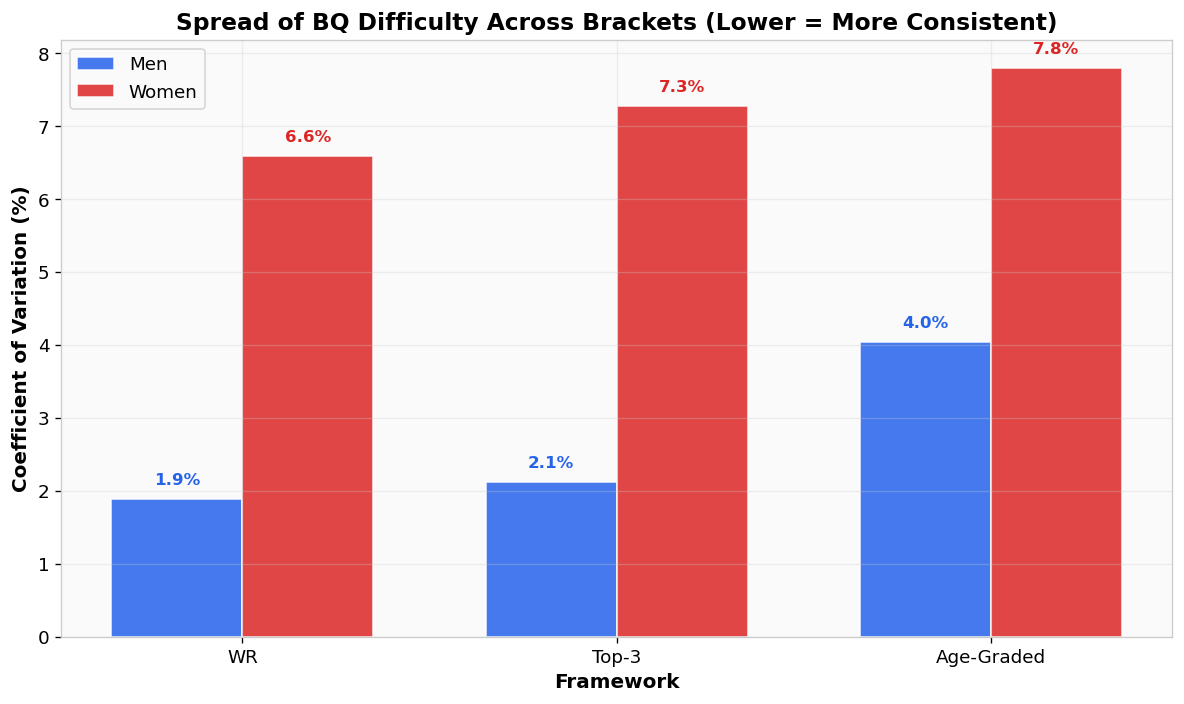

In [8]:
# CV comparison chart
fig, ax = plt.subplots(figsize=(10, 6))

data = {}
for g in ['M', 'W']:
    sub = df[df['gender'] == g]
    for col, label in [('wr_multiplier', 'WR'), ('top3_multiplier', 'Top-3'), ('ag_pct', 'Age-Graded')]:
        cv = sub[col].std() / sub[col].mean() * 100
        data[(label, g)] = cv

frameworks = ['WR', 'Top-3', 'Age-Graded']
x = np.arange(len(frameworks))
width = 0.35

m_cvs = [data[(f, 'M')] for f in frameworks]
w_cvs = [data[(f, 'W')] for f in frameworks]

ax.bar(x - width/2, m_cvs, width, color=BLUE, alpha=0.85, label='Men', edgecolor='white')
ax.bar(x + width/2, w_cvs, width, color=RED, alpha=0.85, label='Women', edgecolor='white')

for i, (m, w) in enumerate(zip(m_cvs, w_cvs)):
    ax.text(i - width/2, m + 0.2, f'{m:.1f}%', ha='center', fontsize=10, fontweight='bold', color=BLUE)
    ax.text(i + width/2, w + 0.2, f'{w:.1f}%', ha='center', fontsize=10, fontweight='bold', color=RED)

ax.set_xlabel('Framework', fontsize=12, fontweight='bold')
ax.set_ylabel('Coefficient of Variation (%)', fontsize=12, fontweight='bold')
ax.set_title('Spread of BQ Difficulty Across Brackets (Lower = More Consistent)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(frameworks)
ax.legend()
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()


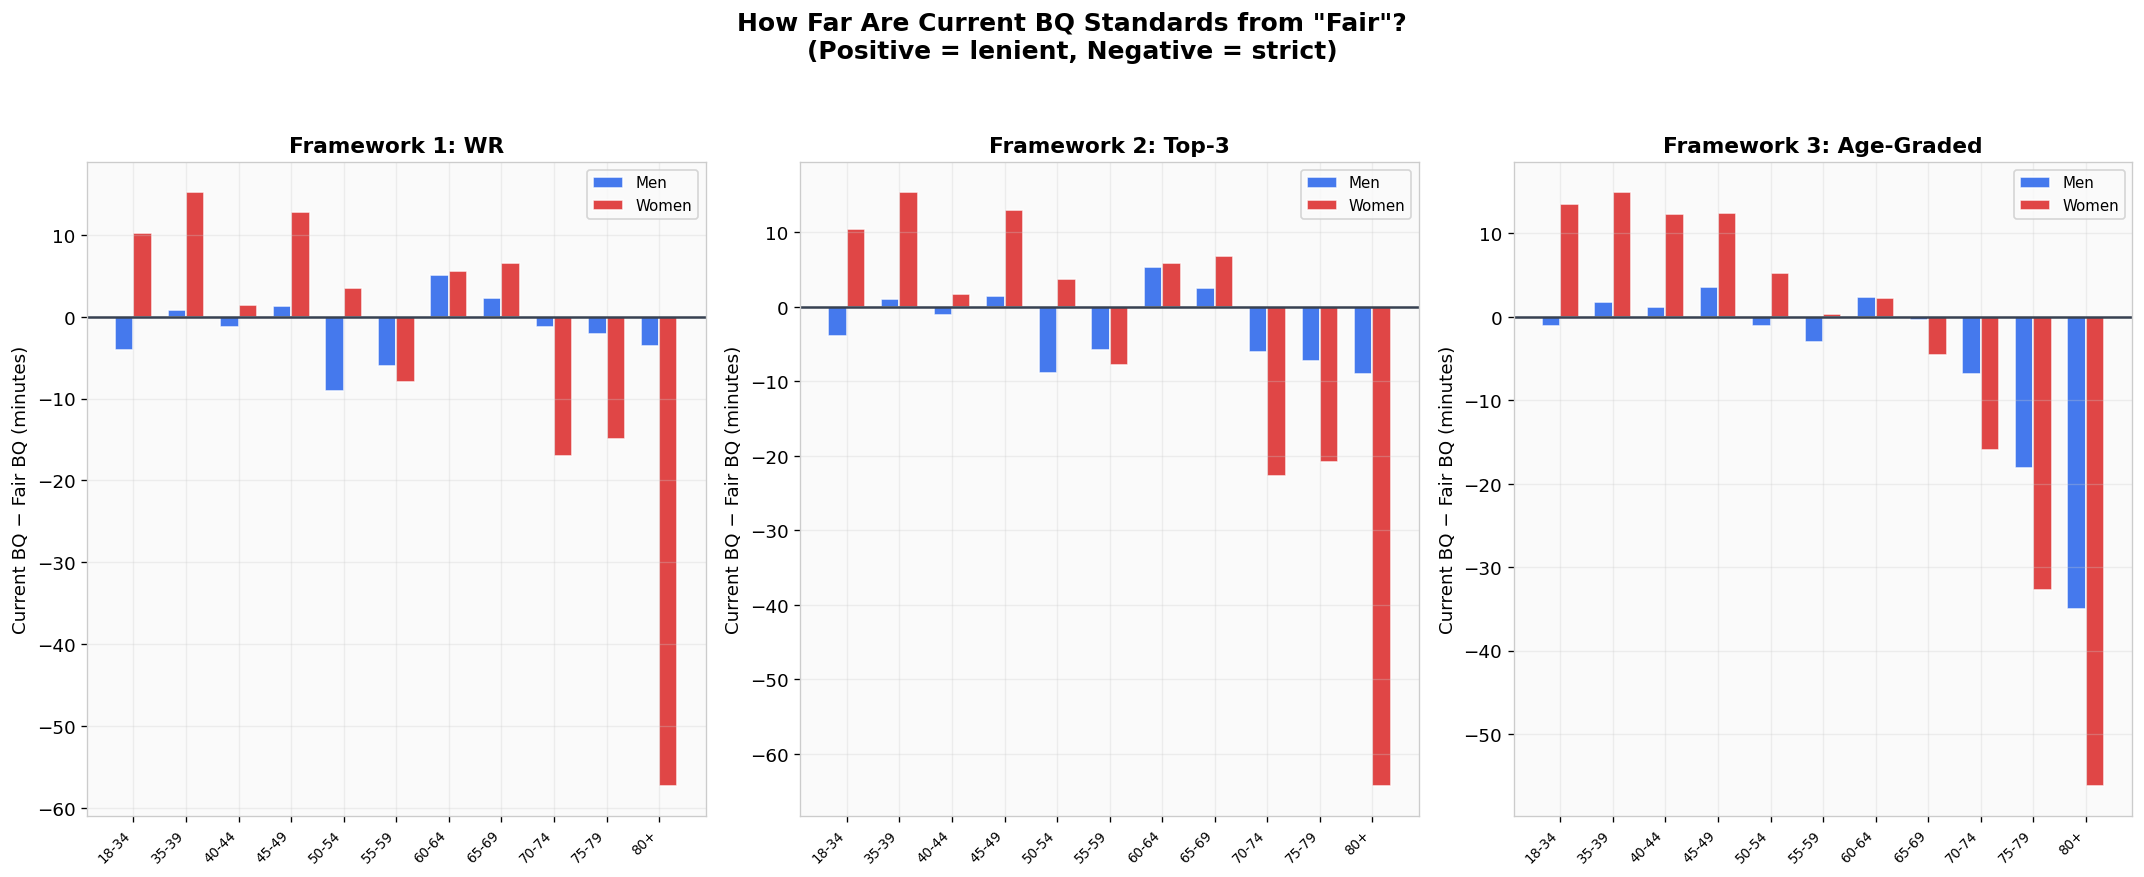

In [9]:
# Fair vs Actual gap chart
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

diff_cols = [
    ('diff_from_fair', 'Framework 1: WR'),
    ('diff_from_fair_top3', 'Framework 2: Top-3'),
    ('diff_from_fair_ag', 'Framework 3: Age-Graded'),
]

for ax, (col, title) in zip(axes, diff_cols):
    age_groups = df['age_group'].unique()
    x = np.arange(len(age_groups))
    width = 0.35
    men = df[df['gender'] == 'M'].set_index('age_group').loc[age_groups]
    women = df[df['gender'] == 'W'].set_index('age_group').loc[age_groups]
    ax.bar(x - width/2, men[col] / 60, width, color=BLUE, alpha=0.85, label='Men', edgecolor='white')
    ax.bar(x + width/2, women[col] / 60, width, color=RED, alpha=0.85, label='Women', edgecolor='white')
    ax.axhline(y=0, color='#374151', linewidth=1.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Current BQ − Fair BQ (minutes)')
    ax.set_xticks(x)
    ax.set_xticklabels(age_groups, rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=9)

fig.suptitle('How Far Are Current BQ Standards from "Fair"?\n(Positive = lenient, Negative = strict)',
             fontsize=15, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()


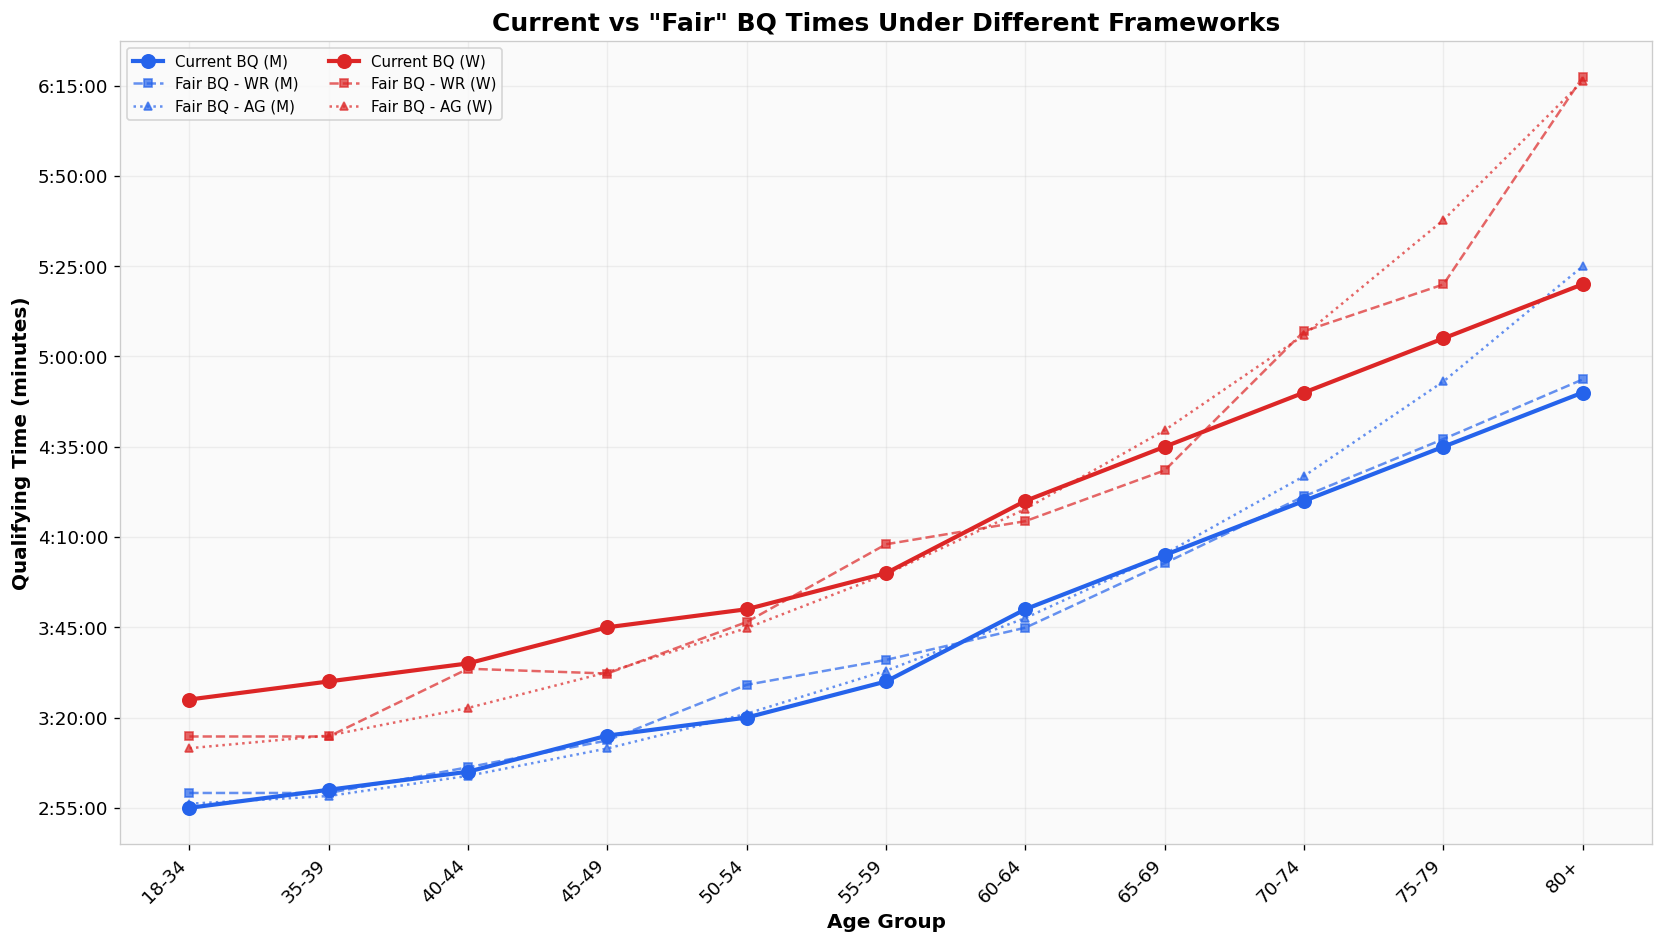

In [10]:
# Current vs Fair BQ times
fig, ax = plt.subplots(figsize=(14, 8))
age_groups = df['age_group'].unique()
x = np.arange(len(age_groups))

for g, color in [('M', BLUE), ('W', RED)]:
    sub = df[df['gender'] == g].set_index('age_group').loc[age_groups]
    ax.plot(x, sub['bq_time_seconds'] / 60, color=color, linewidth=2.5, marker='o', markersize=8, label=f'Current BQ ({g})')
    ax.plot(x, sub['fair_bq_seconds'] / 60, color=color, linewidth=1.5, marker='s', markersize=5, label=f'Fair BQ - WR ({g})', linestyle='--', alpha=0.7)
    ax.plot(x, sub['fair_bq_ag'] / 60, color=color, linewidth=1.5, marker='^', markersize=5, label=f'Fair BQ - AG ({g})', linestyle=':', alpha=0.7)

ax.set_xlabel('Age Group', fontsize=12, fontweight='bold')
ax.set_ylabel('Qualifying Time (minutes)', fontsize=12, fontweight='bold')
ax.set_title('Current vs "Fair" BQ Times Under Different Frameworks', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(age_groups, rotation=45, ha='right')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: time_str(v * 60)))
plt.tight_layout()
plt.show()


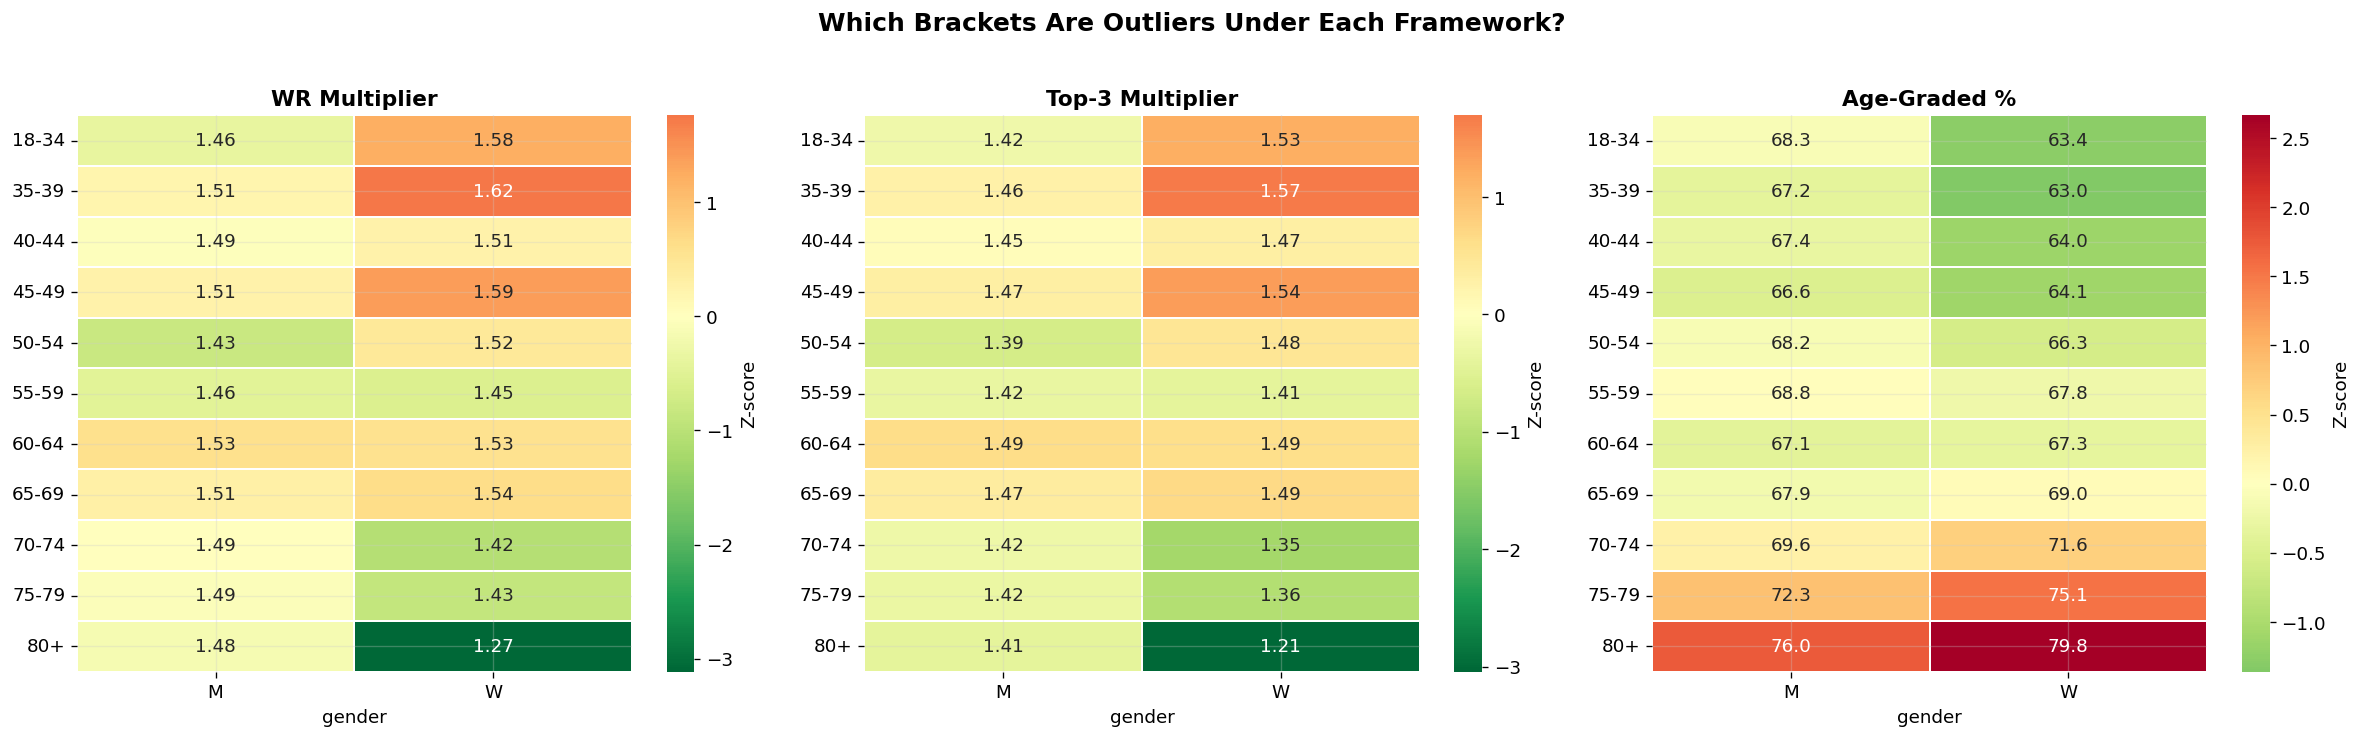

In [11]:
# Deviation heatmaps
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, col, title, fmt in [
    (axes[0], 'wr_multiplier', 'WR Multiplier', '.2f'),
    (axes[1], 'top3_multiplier', 'Top-3 Multiplier', '.2f'),
    (axes[2], 'ag_pct', 'Age-Graded %', '.1f'),
]:
    pivot = df.pivot(index='age_group', columns='gender', values=col)[['M', 'W']]
    overall_mean = df[col].mean()
    overall_std = df[col].std()
    pivot_z = (pivot - overall_mean) / overall_std

    sns.heatmap(pivot_z, annot=pivot, fmt=fmt, cmap='RdYlGn_r', center=0,
                linewidths=1, linecolor='white',
                cbar_kws={'label': 'Z-score'}, ax=ax)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('')

fig.suptitle('Which Brackets Are Outliers Under Each Framework?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 6. Historical Comparison: Did 2026 Tightening Help Fairness?

The 2026 race introduced the largest single tightening of qualifying times since 1990 — five minutes across the board for athletes under 60. Did this also improve fairness across brackets, or did it just shift everything uniformly?


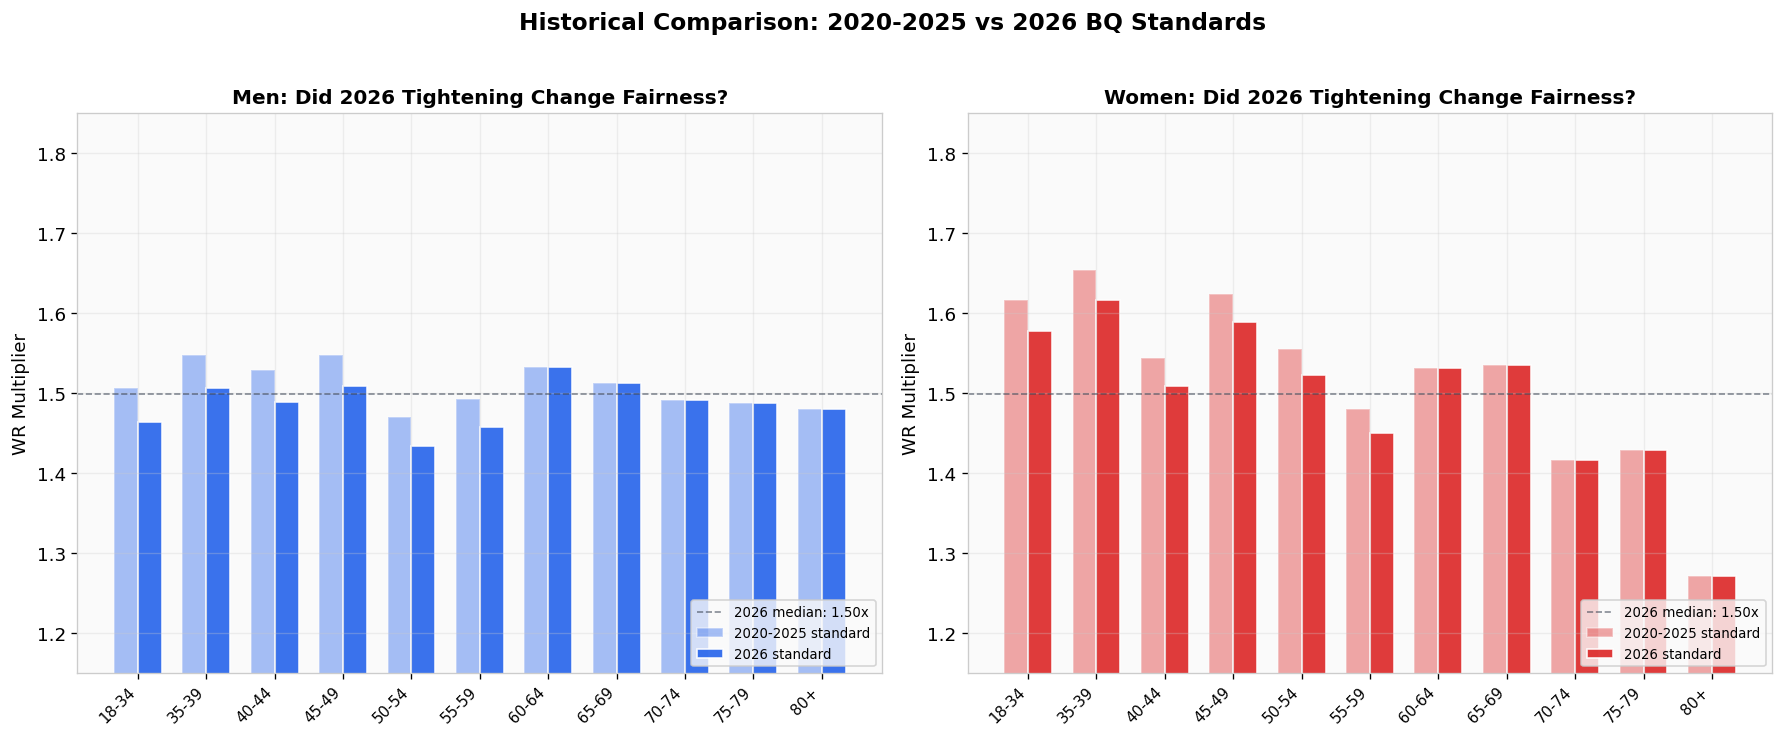

Women's CV (2020-2025): 7.32%
Women's CV (2026):      6.59%
Change:                 -0.73 percentage points

Verdict: the tightening lowered every under-60 multiplier by
roughly the same proportion. The relative bracket structure is unchanged.


In [12]:
# 2020-2025 BQ standards (5 min slower than 2026 for under-60)
historical = {
    ('18-34', 'M'): 10800, ('18-34', 'W'): 12600,
    ('35-39', 'M'): 11100, ('35-39', 'W'): 12900,
    ('40-44', 'M'): 11400, ('40-44', 'W'): 13200,
    ('45-49', 'M'): 12000, ('45-49', 'W'): 13800,
    ('50-54', 'M'): 12300, ('50-54', 'W'): 14100,
    ('55-59', 'M'): 12900, ('55-59', 'W'): 14700,
    ('60-64', 'M'): 13800, ('60-64', 'W'): 15600,  # 60+ unchanged
    ('65-69', 'M'): 14700, ('65-69', 'W'): 16500,
    ('70-74', 'M'): 15600, ('70-74', 'W'): 17400,
    ('75-79', 'M'): 16500, ('75-79', 'W'): 18300,
    ('80+',   'M'): 17400, ('80+',   'W'): 19200,
}

df['bq_2020_seconds'] = df.apply(
    lambda r: historical.get((r['age_group'], r['gender']), r['bq_time_seconds']), axis=1
)
df['mult_2020'] = df['bq_2020_seconds'] / df['wr_time_seconds']

# Plot side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
age_groups = df['age_group'].unique()
x = np.arange(len(age_groups))
width = 0.35

for ax, g, color in [(axes[0], 'M', BLUE), (axes[1], 'W', RED)]:
    sub = df[df['gender'] == g].set_index('age_group').loc[age_groups]
    ax.bar(x - width/2, sub['mult_2020'], width, color=color, alpha=0.4,
           label='2020-2025 standard', edgecolor='white')
    ax.bar(x + width/2, sub['wr_multiplier'], width, color=color, alpha=0.9,
           label='2026 standard', edgecolor='white')
    median_2026 = df['wr_multiplier'].median()
    ax.axhline(y=median_2026, color='#374151', linestyle='--', alpha=0.6, linewidth=1,
               label=f'2026 median: {median_2026:.2f}x')
    ax.set_title(f'{"Men" if g == "M" else "Women"}: Did 2026 Tightening Change Fairness?',
                 fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(age_groups, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('WR Multiplier')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_ylim(1.15, 1.85)

fig.suptitle('Historical Comparison: 2020-2025 vs 2026 BQ Standards', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Compute historical CV vs 2026 CV
w_2020 = df[df['gender']=='W']['mult_2020']
w_2026 = df[df['gender']=='W']['wr_multiplier']
cv_2020 = w_2020.std() / w_2020.mean() * 100
cv_2026 = w_2026.std() / w_2026.mean() * 100
print(f"Women's CV (2020-2025): {cv_2020:.2f}%")
print(f"Women's CV (2026):      {cv_2026:.2f}%")
print(f"Change:                 {cv_2026 - cv_2020:+.2f} percentage points")
print()
print("Verdict: the tightening lowered every under-60 multiplier by")
print("roughly the same proportion. The relative bracket structure is unchanged.")


## 7. Sensitivity Analysis: How Robust Are These Conclusions?

We stress-test the main variance-gap finding (women 3-4× more variable than men) against three alternative scenarios:
- **A:** Drop W80+ entirely (remove the largest outlier)
- **B:** Use Sinead Diver's W40 marathon (2:21:34) as the W40-44 reference
- **C:** Use Tigst Assefa's women-only WR (2:15:41) for W18-34


Sensitivity results:
  baseline              M CV: 1.89%   W CV: 6.59%
  drop_W80              M CV: 1.89%   W CV: 4.49%
  stronger_W40          M CV: 1.89%   W CV: 6.60%
  women_only_W18        M CV: 1.89%   W CV: 6.38%


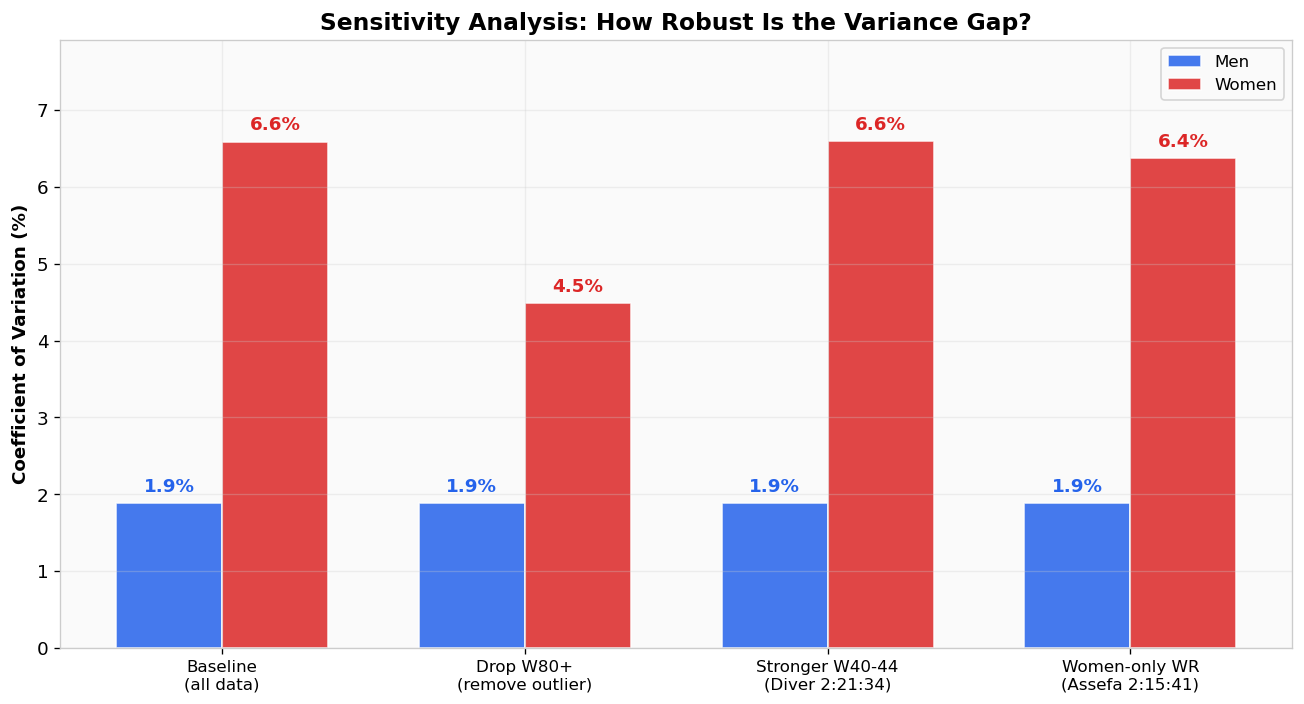

In [13]:
# Sensitivity scenarios
def cv(series):
    return series.std() / series.mean() * 100

base_m = df[df.gender=='M']['wr_multiplier']
base_w = df[df.gender=='W']['wr_multiplier']
scenarios = {'baseline': {'m_cv': cv(base_m), 'w_cv': cv(base_w)}}

# A: Drop W80+
df_a = df[~((df.age_group == '80+') & (df.gender == 'W'))]
scenarios['drop_W80'] = {
    'm_cv': cv(df_a[df_a.gender == 'M']['wr_multiplier']),
    'w_cv': cv(df_a[df_a.gender == 'W']['wr_multiplier']),
}

# B: Use Diver's 2:21:34 (8494s) for W40-44
df_b = df.copy()
mask = (df_b.age_group == '40-44') & (df_b.gender == 'W')
df_b.loc[mask, 'wr_multiplier'] = df_b.loc[mask, 'bq_time_seconds'] / 8494
scenarios['stronger_W40'] = {
    'm_cv': cv(df_b[df_b.gender == 'M']['wr_multiplier']),
    'w_cv': cv(df_b[df_b.gender == 'W']['wr_multiplier']),
}

# C: Use Assefa's women-only WR (8141s) for W18-34
df_c = df.copy()
mask = (df_c.age_group == '18-34') & (df_c.gender == 'W')
df_c.loc[mask, 'wr_multiplier'] = df_c.loc[mask, 'bq_time_seconds'] / 8141
scenarios['women_only_W18'] = {
    'm_cv': cv(df_c[df_c.gender == 'M']['wr_multiplier']),
    'w_cv': cv(df_c[df_c.gender == 'W']['wr_multiplier']),
}

print("Sensitivity results:")
for name, vals in scenarios.items():
    print(f"  {name:20s}  M CV: {vals['m_cv']:.2f}%   W CV: {vals['w_cv']:.2f}%")

# Plot the sensitivity comparison
fig, ax = plt.subplots(figsize=(11, 6))
order = ['baseline', 'drop_W80', 'stronger_W40', 'women_only_W18']
labels = ['Baseline\n(all data)', 'Drop W80+\n(remove outlier)',
          'Stronger W40-44\n(Diver 2:21:34)', 'Women-only WR\n(Assefa 2:15:41)']
m_cvs = [scenarios[s]['m_cv'] for s in order]
w_cvs = [scenarios[s]['w_cv'] for s in order]

x = np.arange(len(order))
width = 0.35
ax.bar(x - width/2, m_cvs, width, color=BLUE, alpha=0.85, label='Men', edgecolor='white')
ax.bar(x + width/2, w_cvs, width, color=RED, alpha=0.85, label='Women', edgecolor='white')

for i, (m, w) in enumerate(zip(m_cvs, w_cvs)):
    ax.text(i - width/2, m + 0.15, f'{m:.1f}%', ha='center', fontweight='bold', color=BLUE)
    ax.text(i + width/2, w + 0.15, f'{w:.1f}%', ha='center', fontweight='bold', color=RED)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Coefficient of Variation (%)', fontsize=11, fontweight='bold')
ax.set_title('Sensitivity Analysis: How Robust Is the Variance Gap?', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, max(w_cvs) * 1.2)
plt.tight_layout()
plt.show()


## 8. Key Findings

### Finding 1: No Mean-Level Gender Bias
Under all frameworks, the average difficulty for men and women is statistically indistinguishable (p > 0.68). The BAA has calibrated the average correctly across genders.

### Finding 2: Women's Brackets Are 3-4× More Variable
CV for men: 1.9-4.0% across frameworks. For women: 6.6-7.8%. This is driven by outlier reference records and thinner competition depth in older women's brackets.

### Finding 3: W80+ Is the Most Miscalibrated Bracket
Under WR: 57 minutes too strict. Under age-grading: 56 minutes too strict. This holds across all three frameworks.

### Finding 4: The 2026 Tightening Did Not Change Fairness Structure
Women's CV moved from ~6.8% (2020-2025) to 6.6% (2026) — essentially unchanged. The tightening responded to demand, not to inter-bracket fairness.

### Finding 5: W80+ Alone Drives ~⅓ of Women's Variance
The sensitivity analysis shows that removing W80+ alone drops women's CV from 6.6% to 4.5%.

## 9. Limitations

- **Single-record dependence**: Thin brackets (especially older women's) are dominated by one extraordinary athlete
- **Under-35 ambiguity**: Open WR used for 18-34 and 35-39 brackets since no separate masters record is faster
- **Top-3 estimation**: Framework 2 uses fixed depth factors rather than verified data
- **Fairness is multi-dimensional**: The BAA may legitimately optimize for objectives other than difficulty-parity (field-size diversity, participation encouragement, etc.)
- **Statistical power**: n = 11 per gender; formal tests are underpowered


In [14]:
# Final summary table
summary = df[['age_group', 'gender', 'bq_time_hhmmss', 'wr_multiplier',
              'top3_multiplier', 'ag_pct',
              'fair_bq_hhmmss', 'fair_bq_ag_hhmmss']].copy()
summary.columns = ['Age Group', 'Gender', 'Current BQ', 'WR Mult',
                    'Top-3 Mult', 'AG%', 'Fair BQ (WR)', 'Fair BQ (AG)']
summary['WR Mult'] = summary['WR Mult'].round(3)
summary['Top-3 Mult'] = summary['Top-3 Mult'].round(3)
summary['AG%'] = summary['AG%'].round(1)
summary


,Age Group,Gender,Current BQ,WR Mult,Top-3 Mult,AG%,Fair BQ (WR),Fair BQ (AG)
0,18-34,M,2:55:00,1.464,1.422,68.3,2:59:07,2:56:08
1,18-34,W,3:25:00,1.578,1.532,63.4,3:14:45,3:11:30
2,35-39,M,3:00:00,1.506,1.462,67.2,2:59:07,2:58:16
3,35-39,W,3:30:00,1.616,1.569,63.0,3:14:45,3:15:01
4,40-44,M,3:05:00,1.489,1.446,67.4,3:06:14,3:03:51
5,40-44,W,3:35:00,1.509,1.465,64.0,3:33:31,3:22:39
6,45-49,M,3:15:00,1.509,1.465,66.6,3:13:39,3:11:27
7,45-49,W,3:45:00,1.589,1.543,64.1,3:32:11,3:32:33
8,50-54,M,3:20:00,1.434,1.392,68.2,3:29:04,3:21:04
9,50-54,W,3:50:00,1.522,1.478,66.3,3:46:27,3:44:46
